### Logistic Regression is a classifier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix



In [3]:
# create Dataset
data = {
    "Hours_Studied": [1,2,3,4,5,6,7,8,9,10],
    "Passed":[0,0,0,0,0,1,1,1,1,1]
}

df = pd.DataFrame(data)

X = df[['Hours_Studied']] # Feature Input Vector
y = df[['Passed']] # Target Feature Vector

In [4]:
# Split data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [5]:
# Train LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [6]:
#Make Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # Probability of pass or fail


In [8]:
#Evaluation of the Model
print("Confusion Matrix: \n",confusion_matrix(y_test,y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

Confusion Matrix: 
 [[1 0]
 [0 1]]
Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


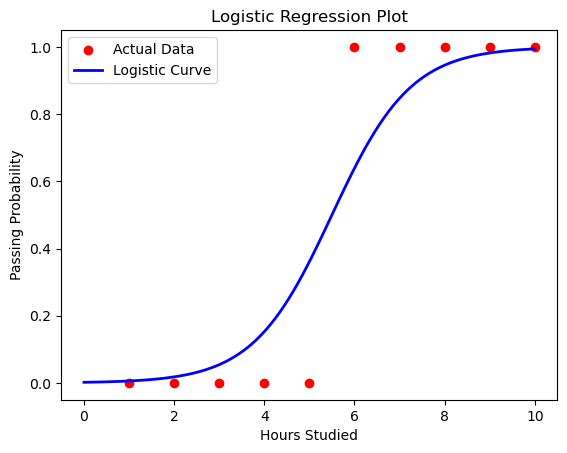

In [12]:
X_range = np.linspace(0,10,100).reshape(-1,1)
y_prob_curve = model.predict_proba(X_range)[:,1]
plt.scatter(df["Hours_Studied"], df['Passed'], color='red', label = "Actual Data")
plt.plot(X_range,y_prob_curve, color = 'blue', linewidth = 2, label = 'Logistic Curve')
plt.xlabel("Hours Studied")
plt.ylabel("Passing Probability")
plt.title('Logistic Regression Plot')
plt.legend()
plt.show()